1. **Creating a Custom Dataset for your files**

    A custom Dataset class must implement three functions: __init__, __len__, and __getitem__. Take a look at this implementation; the SatelliteImageClassification images are stored in a directory img_dir, and their labels are stored separately in a CSV file annotations_file.

    ```
    __init__
    ```
    The \__init__ function is run once when instantiating the Dataset object. We initialize the annotations file, and both transforms 


    ```
    __len__
    ```
    The \__len__ function returns the number of samples in our dataset.


    ```
    __getitem__
    ```
    The \__getitem__ function loads and returns a sample from the dataset at the given index idx. Based on the index, it identifies the image’s location on disk, converts that to a tensor using read_image, retrieves the corresponding label from the csv data in self.img_labels, calls the transform functions on them (if applicable), and returns the tensor image and corresponding label in a tuple.

In [1]:
import os
import torch
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image


class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, str(self.img_labels.iloc[idx, 0]))
        label = self.img_labels.iloc[idx, 1]

        # Load image
        image = Image.open(img_path).convert('RGB')
        # transform to torch
        label = label.astype('float32')
        # label = torch.from_numpy(label) 

        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

        - Preparing your data for training with DataLoaders

In [2]:
import torchvision.transforms.v2 as transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToImage(),  # Convert to image format
    transforms.ConvertImageDtype(torch.float32),  # Convert image dtype
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])


target_transform = transforms.Compose([
    transforms.ToDtype(torch.float32)  # Convert torch.float32
    ])


test_dataset = CustomImageDataset(annotations_file='./AgeDetection/test_annotation.csv', img_dir='./AgeDetection', transform=transform)
test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=True)

        - Iterate through the DataLoader

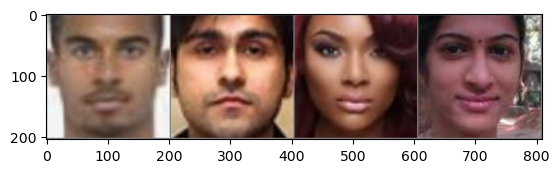

29.0 26.0 29.0 27.0


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(test_dataloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{labels[j]}' for j in range(4)))

2. Define a Convolutional Neural Network

In [4]:
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn as nn

# New weights with accuracy 80.858%
model = resnet50()
model.fc = nn.Linear(2048, 1)
model.load_state_dict(torch.load('./age_model.pt'))


<All keys matched successfully>

3. Test the network (Dataloader)

In [5]:
from torch.nn.functional import mse_loss

# Check if GPU (cuda) is available
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Move our model to device (GPU or CPU)
model.to(device)
model.eval()

n_data = 0
mse = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs = inputs.to(device)
        
        # calculate outputs by running images through the network
        outputs = model(inputs)
        outputs = outputs.squeeze(1)
        
        outputs= outputs.cpu()
        
        mse += mse_loss(outputs, labels)
        n_data += 1

print(f'The MSE of the model: {mse//n_data:.02f}')

The MSE of the model: 6.00
